In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

random.seed(123)

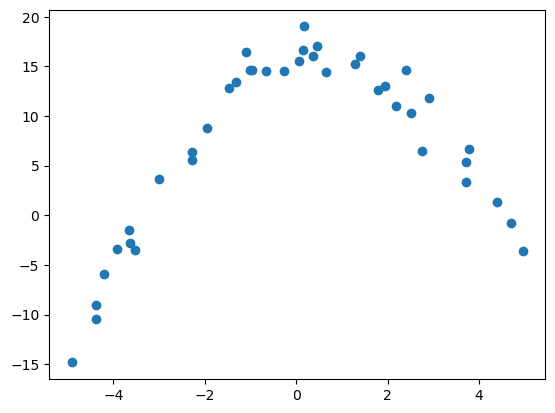

In [15]:
coefs = [15,1,-1]

def polynomial(coefs, x):
    n = len(coefs)
    return sum([coefs[i]*x**i for i in range(n)])

X = []
Y = []
for i in range(40):
    x = random.uniform(-5,5)
    y = polynomial(coefs, x) + random.gauss(0,2)
    X.append(x)
    Y.append(y)

plt.scatter(X,Y)
plt.show()

In [16]:
data = pd.DataFrame({'Y':Y, 'X':X})
for _ in range(2,200):
    data['X'+str(_)] = data['X']**_
data.head()

C:\Users\isaac\AppData\Local\Temp\ipykernel_3744\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['X'+str(_)] = data['X']**_
C:\Users\isaac\AppData\Local\Temp\ipykernel_3744\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['X'+str(_)] = data['X']**_
C:\Users\isaac\AppData\Local\Temp\ipykernel_3744\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

,Y,X,X2,X3,X4,X5,X6,X7,X8,X9,...,X190,X191,X192,X193,X194,X195,X196,X197,X198,X199
0,-1.457124,-3.652724,13.342393,-48.736077,178.019440,-650.255878,2375.205249,-8675.969202,31690.920872,-115758.187049,...,7.892288e+106,-2.882835e+107,1.053020e+108,-3.846391e+108,1.404981e+109,-5.132006e+109,1.874580e+110,-6.847324e+110,2.501139e+111,-9.135969e+111
1,12.773763,-1.479525,2.188993,-3.238670,4.791692,-7.089426,10.488981,-15.518707,22.960310,-33.970346,...,2.104852e+32,-3.114180e+32,4.607507e+32,-6.816920e+32,1.008580e+33,-1.492219e+33,2.207775e+33,-3.266458e+33,4.832805e+33,-7.150254e+33
2,5.604600,-2.280701,5.201599,-11.863295,27.056635,-61.708106,140.737769,-320.980838,732.061471,-1669.613678,...,1.078957e+68,-2.460780e+68,5.612304e+68,-1.279999e+69,2.919296e+69,-6.658042e+69,1.518501e+70,-3.463247e+70,7.898632e+70,-1.801442e+71
3,-3.393226,-3.913792,15.317765,-59.950541,234.633928,-918.308311,3594.067403,-14066.431008,55053.080299,-215466.286266,...,3.922505e+112,-1.535187e+113,6.008402e+113,-2.351563e+114,9.203529e+114,-3.602069e+115,1.409775e+116,-5.517565e+116,2.159460e+117,-8.451677e+117
4,-9.033894,-4.373912,19.131108,-83.677789,365.999308,-1600.848858,7001.972432,-30626.013005,133955.493505,-585909.574226,...,5.825223e+121,-2.547901e+122,1.114430e+123,-4.874418e+123,2.132028e+124,-9.325302e+124,4.078805e+125,-1.784034e+126,7.803206e+126,-3.413054e+127


c:\Users\isaac\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.151e+01, tolerance: 2.824e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\isaac\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\isaac\AppData\Local\Temp\ipykernel_3744\2690245876.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_poly['X'+str(_)] = X_poly['X']**_
C:\Users\isaac\AppData\Local\Temp\ipykernel_3744\2690245876.py:24: Performance

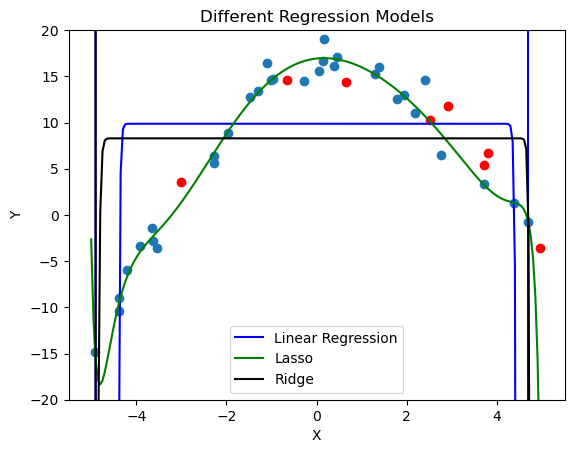

In [23]:
train, test = train_test_split(data, test_size=0.2)
X_train = train.drop('Y', axis=1)
X_test = test.drop('Y', axis=1)

linear = LinearRegression()
linear1 = Lasso(alpha = 0.1)
linear2 = Ridge(alpha = 0.1)

linear.fit(X_train, train['Y'])
linear1.fit(X_train, train['Y'])
linear2.fit(X_train, train['Y'])

predit = data.drop('Y', axis=1)
pred_y = linear.predict(predit)
pred_y1 = linear1.predict(predit)
pred_y2 = linear2.predict(predit)

plt.scatter(train['X'], train['Y'])
plt.scatter(test['X'], test['Y'], color='red')

X_range = np.linspace(-5, 5, 200)
X_poly = pd.DataFrame({'X':X_range})
for _ in range(2,200):
    X_poly['X'+str(_)] = X_poly['X']**_
Y_pred = linear.predict(X_poly)
Y_pred1 = linear1.predict(X_poly)
Y_pred2 = linear2.predict(X_poly)

plt.plot(X_range, Y_pred, color='blue', label='Linear Regression')
plt.plot(X_range, Y_pred1, color='green', label='Lasso')
plt.plot(X_range, Y_pred2, color='black', label='Ridge')

plt.legend()
plt.ylim(-20, 20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Different Regression Models")
plt.show()
